### 설정 및 불러오기

In [ ]:
import os
import kagglehub
from google.colab import drive

drive.mount('/content/drive')

print("Downloading PACS dataset via kagglehub...")
path = kagglehub.dataset_download("ma3ple/pacs-dataset")

print("Path to dataset files:", path)

if not os.path.exists('PACS'):
    os.symlink(path, 'PACS')
    print("Created symbolic link: PACS ->", path)

print("Available domains:", os.listdir('PACS'))
current_path = 'PACS'
while 'art_painting' not in [d.lower() for d in os.listdir(current_path)]:
    subdirs = [d for d in os.listdir(current_path) if os.path.isdir(os.path.join(current_path, d))]
    if not subdirs:
        break
    current_path = os.path.join(current_path, subdirs[0])

DATA_ROOT = current_path
print(f"최종 데이터 경로: {DATA_ROOT}")
print(f"발견된 도메인: {os.listdir(DATA_ROOT)}")

### 불러오기 & 하이퍼파라미터

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image, ImageOps, ImageDraw
import torch
from tqdm import tqdm # 진행상황 표시바
import shutil
import random, math
from torch.utils.data import Dataset, DataLoader
from concurrent.futures import ProcessPoolExecutor

# --- 랜덤 seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- 하이퍼파라미터 ---
BATCH_SIZE    = 32
LR            = 0.01
EPOCHS        = 80
WARMUP_EPOCHS = 4
WEIGHT_DECAY  = 5e-4
IMG_SIZE      = 224
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
swa_start     = int(EPOCHS * 0.75)

# --- 설정 ---
data_root = 'PACS'
drive_root = '/content/drive/MyDrive/pacs'
photo_root = 'PACS/kfold/photo'                      # 원본 Photo 데이터 경로
sketch_root = os.path.join(drive_root, 'processed_pacs')  # 데이터 셋 저장 경로

### 데이터 전처리 후 저장

In [ ]:
def process_and_save_image(img_path, save_path):
  try:
    # 1. 이미지 로드
    img_pil = Image.open(img_path).convert("RGB")
    img = np.array(img_pil)
    h, w = img.shape[:2]

    if img.shape[0] < 10 or img.shape[1] < 10:
        img_pil.save(save_path)
        return

    # 2. 마스크 초기화
    mask = np.zeros(img.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    # 3. 사각형(ROI) 지정 (테두리 10% 빼기)
    margin_h = int(h * 0.08)
    margin_w = int(w * 0.08)
    rect = (margin_w, margin_h, w - 2 * margin_w, h - 2 * margin_h)
    cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

    # 5. 마스크 정리
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

    if np.sum(mask2) < (h * w * 0.03): img_fg = img.copy()
    else:
      img_fg = img * mask2[:, :, np.newaxis]  
    img_fg[mask2 == 0] = [255, 255, 255]

    if category.lower() == 'person' and random.random() < 0.1:
      person_pil = Image.fromarray(cv2.cvtColor(img_fg, cv2.COLOR_BGR2RGB))
      output_size = 224
      scale = random.uniform(0.3, 0.45) 
      new_size = int(output_size * scale)
      person_resized = person_pil.resize((new_size, new_size), Image.LANCZOS)
      # 하얀 캔버스 생성
      canvas = Image.new("RGB", (output_size, output_size), (255, 255, 255))

      offset_x = (output_size - new_size) // 2
      offset_y = random.randint(10, 30) # 상단에 배치
      canvas.paste(person_resized, (offset_x, offset_y))

      draw = ImageDraw.Draw(canvas)
      # 턱 위치 
      neck_x, neck_y = offset_x + new_size // 2, offset_y + new_size - 5

      body_len = random.randint(50, 70)
      body_end_x, body_end_y = neck_x, neck_y + body_len
      draw.line([(neck_x, neck_y), (body_end_x, body_end_y)], fill=(0, 0, 0), width=2)

      # 2. 팔 (각도 랜덤화)
      arm_angle = random.uniform(math.pi/6, math.pi/2) 
      arm_len = 40
      for side in [-1, 1]: 
          hand_x = neck_x + side * arm_len * math.cos(arm_angle)
          hand_y = neck_y + 10 + arm_len * math.sin(arm_angle)
          draw.line([(neck_x, neck_y + 10), (hand_x, hand_y)], fill=(0, 0, 0), width=2)

      # 3. 다리 (무릎 관절 추가)
      leg_angle = random.uniform(math.pi/6, math.pi/3) # 다리 벌림 각도
      upper_leg_len = 25
      lower_leg_len = 25
      for side in [-1, 1]:
          # 허벅지
          knee_x = body_end_x + side * upper_leg_len * math.sin(leg_angle)
          knee_y = body_end_y + upper_leg_len * math.cos(leg_angle)
          draw.line([(body_end_x, body_end_y), (knee_x, knee_y)], fill=(0, 0, 0), width=2)
          # 종아리 (살짝 안쪽/바깥쪽으로 꺾기)
          foot_x = knee_x + side * lower_leg_len * math.sin(leg_angle + random.uniform(-0.2, 0.2))
          foot_y = knee_y + lower_leg_len * math.cos(leg_angle)
          draw.line([(knee_x, knee_y), (foot_x, foot_y)], fill=(0, 0, 0), width=2)

      img_fg = np.array(canvas)

    # 6. Canny Edge 적용
    # 흑백 변환
    img_gray = cv2.cvtColor(img_fg, cv2.COLOR_RGB2GRAY)
    if category.lower() == 'person': edges = cv2.Canny(img_gray, 40, 100)
    elif category.lower() == 'house': edges = cv2.Canny(img_gray, 40, 100)
    elif category.lower() == 'dog': edges = cv2.Canny(img_gray, 40, 100)
    else: edges = cv2.Canny(img_gray, 30, 100)

    kernel = np.ones((2, 2), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)

    final_img = Image.fromarray(edges)
    final_img.save(save_path)

  except Exception as e:
    print(f"Error processing {img_path}: {e}")

In [ ]:
# --- 폴더 초기화 함수 ---
def reset_folder(path):
    if os.path.exists(path):
        print(f"기존 폴더 삭제 : {path}")
        shutil.rmtree(path)  

    os.makedirs(path, exist_ok=True) 
    print(f"새 폴더 생성 완료! : {path}")

# --- 래퍼 함수 ---
def task_wrapper(args):
    src, dst = args
    process_and_save_image(src, dst)

# --- 3. 전체 데이터셋 순회 및 처리 ---
print(f"데이터 변환 시작: {photo_root} -> {sketch_root}")

scs = []
while True:
  sc = input("전처리할 카테고리 선택(all: 전부, 0: 종료): ")
  if sc == 'all':
    sc = []
    break
  elif sc == '0':
    break
  else: scs.append(sc)

# 카테고리 폴더 순회
for category in os.listdir(photo_root):
  if len(scs) != 0 and category not in scs: continue

  category_path = os.path.join(photo_root, category)
  save_category_path = os.path.join(sketch_root, category)

  if not os.path.isdir(category_path): continue

  # 저장할 폴더 삭제 후 생성
  reset_folder(save_category_path)
  files = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

  tasks = []
  for fname in files:
    src = os.path.join(category_path, fname)
    dst = os.path.join(save_category_path, fname)
    tasks.append((src, dst))

  with ProcessPoolExecutor() as executor:
    list(tqdm(executor.map(task_wrapper, tasks),
      total=len(tasks),
      desc=f"Parallel Processing {category}"))


### 데이터 증강 & 로드

In [ ]:
# --- 전처리 ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9), 
    transforms.RandomRotation(15, fill=255),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), value=-1) 
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),
    transforms.Lambda(lambda x: (x > 0.5).float()),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# --- 도메인 분류 ---
all_domain_folders = os.listdir(data_root)
train_domains = ['photo'] #'art_painting', 'cartoon',
test_domain = 'sketch'

In [ ]:
# --- new 클래스 가중치 계산  ---
class_counts = np.array([len(os.listdir(os.path.join(photo_root, c)))
                          for c in sorted(os.listdir(photo_root))])
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 7
class_weights = class_weights.to(DEVICE)

# --- 도메인 분류 및 데이터 로더 ---
train_dataset = datasets.ImageFolder(sketch_root, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Train Domain: photo | Images: {len(train_dataset)}")

test_dataset = datasets.ImageFolder(os.path.join(data_root, 'kfold', 'sketch'), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Test Domain: sketch | Images: {len(test_dataset)}")

Train Domain: photo | Images: 1670
Test Domain: sketch | Images: 3929


In [ ]:
def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    W, H = x.size(3), x.size(2)
    cut_w = int(W * math.sqrt(1.0 - lam))
    cut_h = int(H * math.sqrt(1.0 - lam))
    cx, cy = random.randint(0, W), random.randint(0, H)
    x1, y1 = max(cx - cut_w//2, 0), max(cy - cut_h//2, 0)
    x2, y2 = min(cx + cut_w//2, W), min(cy + cut_h//2, H)
    mixed = x.clone()
    mixed[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    return mixed, y, y[idx], 1 - (x2-x1)*(y2-y1)/(W*H)

### 사진 시각화 부분

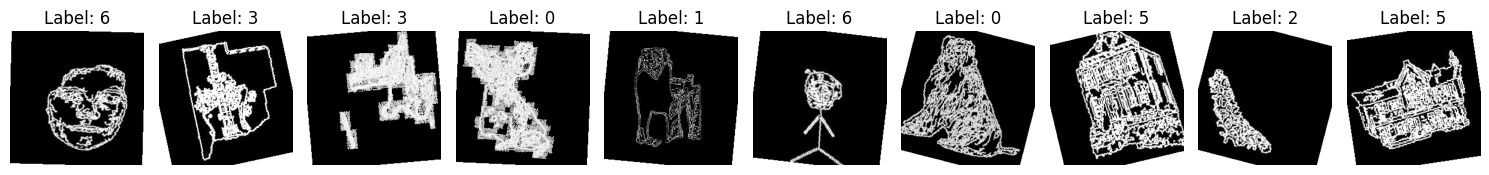

In [ ]:
# --- 시각화 ---
if train_loader is None:
  print("시각화 x")
else:
  num_images = 10
  images, labels = next(iter(train_loader))

  images = images[:num_images]
  labels = labels[:num_images]

  plt.figure(figsize=(15, 5))
  for i in range(num_images):
      ax = plt.subplot(1, num_images, i + 1)

      # Denormalize
      img = np.clip(images[i].numpy() * 0.5 + 0.5, 0, 1)

      # 차원 변경: (C, H, W) -> (H, W, C) 
      img = np.transpose(img, (1, 2, 0))

      # 1채널(Grayscale)인 경우 cmap='gray' 사용
      if img.shape[2] == 1:
          img = img.squeeze(2) 
          plt.imshow(img, cmap='gray')
      else:
          plt.imshow(img)

      plt.title(f"Label: {labels[i].item()}")
      plt.axis('off')

  plt.tight_layout()
  plt.show()

### 레이어 정의

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

# --- IBN ---
class IBN(nn.Module):
    def __init__(self, planes):
        super(IBN, self).__init__()
        self.half = int(planes / 2)
        self.IN = nn.InstanceNorm2d(self.half, affine=True)
        self.BN = nn.BatchNorm2d(planes - self.half)

    def forward(self, x):
        split = torch.split(x, self.half, 1)
        out1 = self.IN(split[0].contiguous())
        out2 = self.BN(split[1].contiguous())
        out = torch.cat((out1, out2), 1)
        return out

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class IBN_SE_BasicBlock(models.resnet.BasicBlock):
    def __init__(self, *args, **kwargs):
        super(IBN_SE_BasicBlock, self).__init__(*args, **kwargs)
        self.bn1 = IBN(self.bn1.num_features)
        self.se = SEBlock(self.conv2.out_channels)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.se(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d)):
            if m.affine:
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

def get_advanced_resnet18(device):
    model = models.resnet18(weights=None)

    # Layer 1 (64, 64)
    model.layer1 = nn.Sequential(
        IBN_SE_BasicBlock(64, 64),
        IBN_SE_BasicBlock(64, 64)
    )

    # Layer 2 (64, 128)
    downsample_2 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
        nn.BatchNorm2d(128),
    )
    model.layer2 = nn.Sequential(
        IBN_SE_BasicBlock(64, 128, stride=2, downsample=downsample_2),
        IBN_SE_BasicBlock(128, 128)
    )

    # Layer 3 (128, 256)
    downsample_3 = nn.Sequential(
        nn.Conv2d(128, 256, kernel_size=1, stride=2, bias=False),
        nn.BatchNorm2d(256),
    )
    model.layer3 = nn.Sequential(
        IBN_SE_BasicBlock(128, 256, stride=2, downsample=downsample_3),
        IBN_SE_BasicBlock(256, 256)
    )

    # Layer 4 (256, 512)
    downsample_4 = nn.Sequential(
        nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False),
        nn.BatchNorm2d(512),
    )
    model.layer4 = nn.Sequential(
        IBN_SE_BasicBlock(256, 512, stride=2, downsample=downsample_4),
        IBN_SE_BasicBlock(512, 512)
    )

    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    nn.init.kaiming_normal_(model.conv1.weight, mode='fan_out', nonlinearity='relu')

    model.fc = nn.Linear(512, 7)

    initialize_weights(model)
    return model.to(device)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_advanced_resnet18(DEVICE)
swa_model = AveragedModel(model).to(DEVICE)

In [ ]:
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing
        self.register_buffer('weight', weight)

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        log_probs = torch.nn.functional.log_softmax(pred, dim=-1)

        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)

        if self.weight is not None:
          nll_loss = nll_loss * self.weight[target]

        smooth_loss = -log_probs.mean(dim=-1)

        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

In [ ]:
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR

criterion = LabelSmoothingCrossEntropy(smoothing=0.15, weight=class_weights)
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=WEIGHT_DECAY)

warmup_lambda = lambda epoch: (epoch + 1) / WARMUP_EPOCHS
warmup_scheduler = LambdaLR(optimizer, lr_lambda=warmup_lambda)

swa_scheduler = SWALR(optimizer, swa_lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=swa_start - WARMUP_EPOCHS, eta_min=1e-5)

In [ ]:
# --- mixup, cutmix ---
MIXUP_ALPHA  = 0.2
CUTMIX_ALPHA = 0.8    # new
MIXUP_PROB   = 0.5
CUTMIX_PROB  = 0.3    # new

def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        r = random.random()
        if r < MIXUP_PROB:
          images, y_a, y_b, lam = mixup_data(images, labels, alpha=MIXUP_ALPHA)
        elif r < MIXUP_PROB + CUTMIX_PROB:
          images, y_a, y_b, lam = cutmix_data(images, labels, CUTMIX_ALPHA)
        else:
          y_a, y_b, lam = labels, labels, 1.0

        optimizer.zero_grad()
        outputs = model(images)
        loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (lam * predicted.eq(y_a).sum().item() +
                    (1 - lam) * predicted.eq(y_b).sum().item())

    if epoch >= swa_start:
        swa_model.update_parameters(model)
        swa_scheduler.step()
        current_lr = swa_scheduler.get_last_lr()[0]
    else:
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f} | Loss: {running_loss/len(train_loader):.4f} | Train: {100.*correct/total:.2f}% | ", end='')

def evaluate_ood(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
      for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs_orig = model(images)

        images_flipped = torch.flip(images, dims=[3])
        outputs_flipped = model(images_flipped)

        avg_outputs = (outputs_orig + outputs_flipped) / 2

        _, predicted = avg_outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    print(f"Test: {accuracy:.2f}%")
    return accuracy

### 학습

In [43]:
# --- 실행 ---
print("Challenge Start!")
# model.load_state_dict(torch.load('/content/drive/MyDrive/pacs/swa_bset_model1.pth'))
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_one_epoch(epoch)

    val_acc = evaluate_ood(model, test_loader)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), os.path.join(drive_root, 'test1'+str(epoch+1)+'pacs_model.pth'))
      print(f"Epoch {epoch+1}: new best accuracy {val_acc:.2f}")


Challenge Start!
Epoch 1/80 | LR: 0.007233 | Loss: 1.7724 | Train: 37.79% | Test: 26.01%
Epoch 1: new best accuracy 26.01
Epoch 2/80 | LR: 0.003621 | Loss: 1.8658 | Train: 37.36% | Test: 21.81%
Epoch 3/80 | LR: 0.000010 | Loss: 1.7498 | Train: 40.05% | Test: 19.32%
Epoch 4/80 | LR: 0.005005 | Loss: 1.6206 | Train: 44.34% | Test: 26.57%
Epoch 4: new best accuracy 26.57
Epoch 5/80 | LR: 0.010000 | Loss: 1.7033 | Train: 41.51% | Test: 22.02%
Epoch 6/80 | LR: 0.005005 | Loss: 1.8793 | Train: 37.42% | Test: 27.00%
Epoch 6: new best accuracy 27.00
Epoch 7/80 | LR: 0.000010 | Loss: 1.6874 | Train: 43.50% | Test: 29.93%
Epoch 7: new best accuracy 29.93
Epoch 8/80 | LR: 0.005005 | Loss: 1.5668 | Train: 43.44% | Test: 22.47%
Epoch 9/80 | LR: 0.010000 | Loss: 1.7142 | Train: 44.21% | Test: 29.24%
Epoch 10/80 | LR: 0.005005 | Loss: 1.6317 | Train: 47.74% | Test: 32.48%
Epoch 10: new best accuracy 32.48
Epoch 11/80 | LR: 0.000010 | Loss: 1.5908 | Train: 50.32% | Test: 41.97%
Epoch 11: new best accu

In [44]:
torch.save(model.state_dict(), os.path.join(drive_root, 'last_model.pth'))

In [45]:
state_dict = torch.load('/content/drive/MyDrive/pacs/best_model_test1.pth')
model.load_state_dict(state_dict)
swa_model = AveragedModel(model).to(DEVICE)

# 최종 OOD 성능 측정
update_bn(train_loader, swa_model, device=DEVICE)
final_acc = evaluate_ood(swa_model, test_loader)
final_acc = evaluate_ood(model, test_loader)

Test: 48.49%
Test: 51.03%


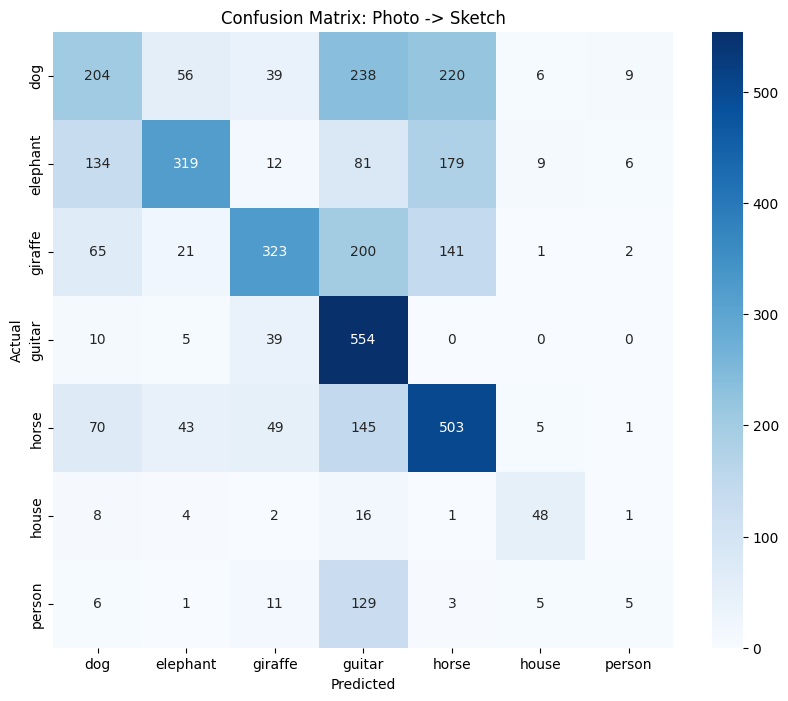


[Classification Report]
              precision    recall  f1-score   support

         dog       0.41      0.26      0.32       772
    elephant       0.71      0.43      0.54       740
     giraffe       0.68      0.43      0.53       753
      guitar       0.41      0.91      0.56       608
       horse       0.48      0.62      0.54       816
       house       0.65      0.60      0.62        80
      person       0.21      0.03      0.05       160

    accuracy                           0.50      3929
   macro avg       0.51      0.47      0.45      3929
weighted avg       0.53      0.50      0.48      3929



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

def analyze_misclassifications(model, test_loader, device):
    # model.load_state_dict(torch.load(load_path))
    model.eval()
    all_preds = []
    all_labels = []
    all_paths = [] 

    class_names = test_loader.dataset.classes

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Confusion Matrix 시각화
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Photo -> Sketch')
    plt.show()

    # 2. 정밀도, 재현율 등 상세 지표 출력
    print("\n[Classification Report]")
    print(classification_report(all_labels, all_preds, target_names=class_names))

analyze_misclassifications(model, test_loader, DEVICE)